In [ ]:
# %pip install scikit-learn, matplotlib
# python -m pip install scikit-learn, matplotlib

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

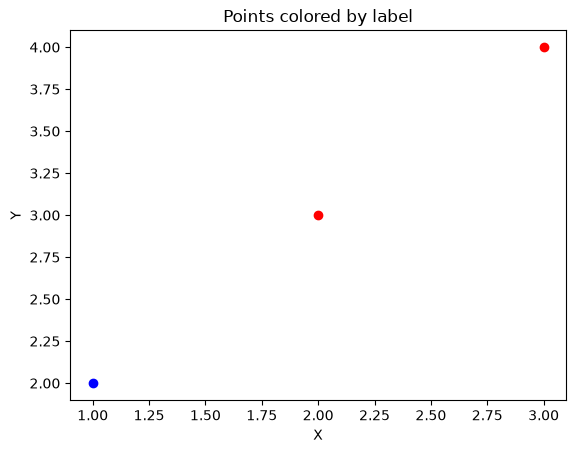

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Points: [x, y]
x = np.array([
    [1, 2],
    [2, 3],
    [3, 4]
])

# Labels
y = np.array([0, 1, 1])

# Plot points with different colors based on y
for i in range(len(x)):
    if y[i] == 0:
        plt.scatter(x[i, 0], x[i, 1], color='blue')
    else:
        plt.scatter(x[i, 0], x[i, 1], color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Points colored by label")
# plt.grid(True)

plt.show()

In [4]:
x = np.array([[1, 2],
              [2, 3],
              [3, 4]])

y = np.array([0, 1, 1])
# np.random.seed(999)
w = np.random.rand(2)

b = 0.0

# Learning rate
eta = 0.1

def step_function(z):
    return 1 if z > 0 else 0

# Training function
def train_slp(x, y, w, b, eta, epochs):
    n_samples, n_features = x.shape

    for epoch in range(epochs):
        total_error = 0.0
        for i in range(n_samples):

            z = np.dot(x[i], w) + b
            
            y_pred = step_function(z)
            
            error = y[i] - y_pred
            
            w += eta * error * x[i]
            # b += eta * error

            total_error += error ** 2
        
        print(f'Epoch {epoch+1}, Total Error: {total_error}, Weights: {w}, Bias: {b}')
        
        if total_error == 0:
            break

    return w, b

# Train the SLP
epochs = 100
w_final, b_final = train_slp(x, y, w, b, eta, epochs)

print(f'Final Weights: {w_final}, Final Bias: {b_final}')

Epoch 1, Total Error: 1.0, Weights: [ 0.42380929 -0.1464248 ], Bias: 0.0
Epoch 2, Total Error: 2.0, Weights: [ 0.52380929 -0.0464248 ], Bias: 0.0
Epoch 3, Total Error: 1.0, Weights: [ 0.42380929 -0.2464248 ], Bias: 0.0
Epoch 4, Total Error: 0.0, Weights: [ 0.42380929 -0.2464248 ], Bias: 0.0
Final Weights: [ 0.42380929 -0.2464248 ], Final Bias: 0.0


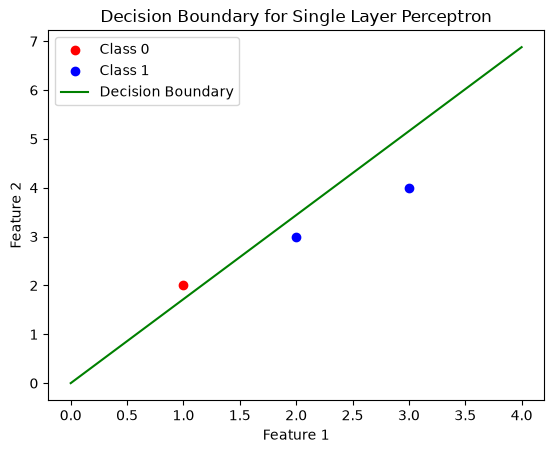

In [5]:
# Plotting the samples
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color='blue', label='Class 1')

# Define the decision boundary (w1 * x1 + w2 * x2 + b = 0)
# 0 = w_final[0] * x1 + w_final[1] * x2 + b_final
# x2 = -(w_final[0] * x1 + b_final)/w_final[1]
x1_vals = np.linspace(min(x[:, 0]) - 1, max(x[:, 0]) + 1, 100)
x2_vals = -(w_final[0] * x1_vals + b_final)/w_final[1]

# Plotting the decision boundary
plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

# Set plot labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary for Single Layer Perceptron')
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
nf = 2
x = np.array(iris.data[:, [3,2]])
y = iris.target

In [ ]:
iris.data.shape

In [ ]:
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color='blue', label='Class 1')
plt.scatter(x[y == 2][:, 0], x[y == 2][:, 1], color='black', label='Class 2')

plt.xlabel('Feature 3')
plt.ylabel('Feature 2')
plt.title('Actual Data Visualization')
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
epochs = 100
w_final, b_final = train_slp(x, y, w, b, eta, epochs)

In [ ]:
w = np.random.rand(x.shape[1])

b = 0.0

# Learning rate
eta = 0.001

# Standardization
scaler = StandardScaler()
xn = scaler.fit_transform(x)

def normalize_weights(weights):
    norm = np.linalg.norm(weights)
    return weights / norm if norm != 0 else weights

def step_function(z):
    if (z > 0.5):
        return 2
    elif (z > 0):
        return 1
    else:
        return 0

# Training function
def train_slp(x, y, w, b, eta, epochs):
    n_samples, n_features = x.shape

    for epoch in range(epochs):
        total_error = 0
        for i in range(n_samples):

            z = np.dot(x[i], w) + b
            
            y_pred = step_function(z)
            
            error = y[i] - y_pred
            
            w += eta * error * x[i]
            b += eta * error

            total_error += error ** 2
            # total_error += np.abs(error)
            
        print(f'Epoch {epoch+1}, Total Error: {total_error}, Weights: {w}, Bias: {b}')
        
        if total_error == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1}, Total Error: {total_error}, Weights: {w}, Bias: {b}')
            break

    return w, b

# Train the SLP
epochs = 1000
w_final, b_final = train_slp(xn, y, w, b, eta, epochs)

In [ ]:
plt.scatter(xn[y == 0][:, 0], xn[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(xn[y == 1][:, 0], xn[y == 1][:, 1], color='blue', label='Class 1')
plt.scatter(xn[y == 2][:, 0], xn[y == 2][:, 1], color='black', label='Class 2')

# x1_vals = np.linspace(min(x[:, 0])*5-1, max(x[:, 0])//10+1, 100)
# x2_vals = -(w_final[0] * x1_vals + b_final)/w_final[1]

# plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary for Single Layer Perceptron')
plt.legend()
# plt.grid(True)
plt.show()

In [37]:
epochs = 1000
scaler = StandardScaler()
xn = scaler.fit_transform(x)
w = np.random.rand(2)
w_final, b_final = train_slp(x[:100,:], y[:100], w, 0.5, 0.1, epochs)

Epoch 1, Total Error: 8.0, Weights: [ 0.07708994 -0.08764221], Bias: 0.5
Epoch 2, Total Error: 5.0, Weights: [ 0.13708994 -0.12764221], Bias: 0.5
Epoch 3, Total Error: 4.0, Weights: [ 0.22708994 -0.04764221], Bias: 0.5
Epoch 4, Total Error: 5.0, Weights: [ 0.29708994 -0.09764221], Bias: 0.5
Epoch 5, Total Error: 5.0, Weights: [ 0.35708994 -0.13764221], Bias: 0.5
Epoch 6, Total Error: 5.0, Weights: [ 0.41708994 -0.17764221], Bias: 0.5
Epoch 7, Total Error: 5.0, Weights: [ 0.48708994 -0.19764221], Bias: 0.5
Epoch 8, Total Error: 4.0, Weights: [ 0.57708994 -0.11764221], Bias: 0.5
Epoch 9, Total Error: 5.0, Weights: [ 0.61708994 -0.18764221], Bias: 0.5
Epoch 10, Total Error: 5.0, Weights: [ 0.67708994 -0.22764221], Bias: 0.5
Epoch 11, Total Error: 5.0, Weights: [ 0.74708994 -0.24764221], Bias: 0.5
Epoch 12, Total Error: 4.0, Weights: [ 0.82708994 -0.17764221], Bias: 0.5
Epoch 13, Total Error: 5.0, Weights: [ 0.86708994 -0.24764221], Bias: 0.5
Epoch 14, Total Error: 4.0, Weights: [ 0.937089

IndexError: index 6 is out of bounds for axis 1 with size 2

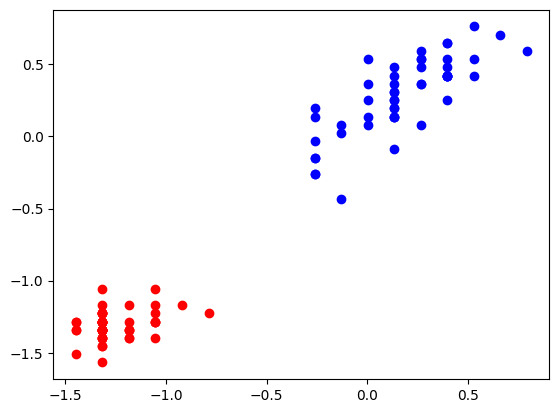

In [49]:
plt.scatter(xn[y == 0][:100, 0], xn[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(xn[y == 1][:100, 0], xn[y == 1][:, 1], color='blue', label='Class 1')
# plt.scatter(xn[y == 2][:100, 0], xn[y == 2][:, 1], color='black', label='Class 2')

x1_vals = np.linspace(min(x[:100, 0])-1, max(x[:100, 6])+1, 10)
x2_vals = -(w_final[0] * x1_vals + b_final)/w_final[1]

plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary for Single Layer Perceptron')
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
x[y[:100]==0,0]

array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
       0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2])